#  Aim : Calculate observed L2FR of FACE Experiments

Data : https://data.ess-dive.lbl.gov/view/doi%3A10.15485%2F1480325#ess-dive-16fdffec778c967-20181119T143344017

In [176]:
pwd

'/Users/ud4/repos/GitHub/FATESFACE/Jupyter_Notebooks/Paper1_Plots'

## Bharat Sharma (bharat.sharma.neu@gmail.com)

In [128]:
import os,glob
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr # to read .rds files

%matplotlib inline





In [129]:
path_in = "/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/"
path_rds = "/Users/ud4/Documents/FACEMDS/Models/obs_data"
path_obs_data = "/Users/ud4/Documents/FACEMDS/L2FR_Calc"
path_save_results = "/Users/ud4/Documents/FACEMDS/Figures_Paper"
#path_save_results = "/Users/ud4/Library/CloudStorage/GoogleDrive-bharat.sharma.neu@gmail.com/My Drive/Documents/PostDocORNL/Papers/Sharma_Walker_ORNL_Papers/Evaluation_Paper_Dir/Results"

## Reading data

In [130]:
# Mean annual files
filename_ORNL  = f"{path_obs_data}/data/ORNL_ax.csv"
filename_DUKE  = f"{path_obs_data}/data/DUKE_ax.csv"

In [131]:
pd.read_csv(filename_ORNL).columns

Index(['year', 'co2', 'fc_grow_wood', 'fc_grow_croot', 'fc_grow_leaf',
       'fc_grow_froot', 'fc_npp', 'c_wood', 'c_croot', 'c_leaf', 'c_froot',
       'fc_leaf_litter', 'fc_froot_to_litter', 'fc_wood_to_litter',
       'fn_leaf_to_litter', 'fn_wood_to_litter', 'n_leaf_peak', 'n_wood',
       'n_croot', 'n_froot', 'fn_grow_leaf', 'fn_grow_wood', 'fn_grow_froot',
       'fn_plantuptake', 'fn_grossmin', 'fn_netmin ', 'ptrait_lai',
       'ptrait_lai_peak', 'fw_transp '],
      dtype='object')

In [132]:
pd.read_csv(filename_DUKE).columns

Index(['year', 'co2', 'c_leaf', 'c_wood', 'c_froot', 'fc_grow_leaf',
       'fc_grow_wood', 'fc_grow_froot', 'fc_grow_repr', 'fc_npp',
       'fc_repr_litter', 'fc_leaf_litter_pine', 'fc_leaf_litter_hardwood',
       'fc_wood_to_litter', 'fc_froot_to_litter', 'n_leaf', 'n_wood',
       'n_froot', 'fn_croot_to_litter', 'fn_wood_to_litter', 'fn_plantuptake',
       'fn_leaf_to_litter', 'fn_leaf_to_store', 'ptrait_lai',
       'ptrait_lai_peak', 'fw_transp '],
      dtype='object')

In [133]:
df_ORNL = pd.read_csv(filename_ORNL)
df_DUKE = pd.read_csv(filename_DUKE)

In [134]:
df_ORNL_select = df_ORNL[['year','co2','c_leaf','c_froot','c_wood','n_wood','n_froot','n_leaf_peak']].copy()
df_ORNL_select = df_ORNL_select.rename(columns={'n_leaf_peak': 'n_leaf'})
df_DUKE_select = df_DUKE[['year','co2','c_leaf','c_froot','c_wood','n_wood','n_froot','n_leaf']].copy()
duke_cols= ['c_leaf','c_froot','c_wood','n_wood','n_froot','n_leaf']
df_DUKE_select [duke_cols] = df_DUKE_select[duke_cols].apply(pd.to_numeric, errors='coerce')

In [144]:
# ORNL

# Compute the ratio c_froot / c_leaf 
df_ORNL_select.loc[:, 'l2fr'] = df_ORNL_select['c_froot'] / df_ORNL_select['c_leaf']
df_ORNL_select.loc[:, 'CN_leaf'] = df_ORNL_select['c_leaf'] / df_ORNL_select['n_leaf']
df_ORNL_select.loc[:, 'CN_froot'] = df_ORNL_select['c_froot'] / df_ORNL_select['n_froot']
df_ORNL_select.loc[:, 'CN_wood'] = df_ORNL_select['c_wood'] / df_ORNL_select['n_wood']
df_ORNL_select = df_ORNL_select.rename(columns={'year': 'Year'})

# Calculate mean ratio for AMB and ELE
mean_l2fr_amb = df_ORNL_select[df_ORNL_select['co2'] == 'AMB']['l2fr'].mean()
mean_l2fr_ele = df_ORNL_select[df_ORNL_select['co2'] == 'ELE']['l2fr'].mean()

dict_obs = {}
dict_obs [f"ORNL_aCO2"] = df_ORNL_select[df_ORNL_select['co2'] == 'AMB'].copy() [["Year", "CN_leaf", "CN_froot", "CN_wood", "l2fr"]]
dict_obs [f"ORNL_eCO2"] = df_ORNL_select[df_ORNL_select['co2'] == 'ELE'].copy() [["Year", "CN_leaf", "CN_froot", "CN_wood", "l2fr"]]


print(f"Mean c_froot/c_leaf for AMB (ORNL): {mean_l2fr_amb:.5f}")
print(f"Mean c_froot/c_leaf for ELE (ORNL): {mean_l2fr_ele:.5f}")

Mean c_froot/c_leaf for AMB (ORNL): 0.31384
Mean c_froot/c_leaf for ELE (ORNL): 0.67438


In [145]:
df_ORNL_select

,Year,co2,c_leaf,c_froot,c_wood,n_wood,n_froot,n_leaf,l2fr,CN_leaf,CN_froot,CN_wood
0,1998,AMB,209.3333,39.00000,4181.667,12.13333,0.580000,7.776667,0.186306,26.918126,67.241379,344.642979
1,1999,AMB,212.3333,71.66667,4586.333,13.56000,1.033333,8.040000,0.337520,26.409614,69.354844,338.225147
2,2000,AMB,225.0000,31.66667,5096.667,15.36000,0.473333,8.116667,0.140741,27.720738,66.901420,331.814258
3,2001,AMB,198.3333,142.33333,5597.333,16.57667,1.830000,6.913333,0.717647,28.688521,77.777776,337.663294
4,2002,AMB,223.0000,79.66667,6117.333,18.14000,1.110000,7.153333,0.357250,31.174279,71.771775,337.228942
5,2003,AMB,236.0000,63.66667,6662.667,19.98667,1.046667,8.020000,0.269774,29.426434,60.828027,333.355531
6,2004,AMB,206.3333,116.33333,7040.667,21.06667,1.690000,7.126667,0.563813,28.952286,68.836290,334.208824
7,2005,AMB,225.3333,48.66667,7494.667,21.98667,0.806667,7.063333,0.215976,31.901837,60.330580,340.873220
8,2006,AMB,231.0000,37.33333,7837.667,22.73000,0.616667,6.473333,0.161616,35.684863,60.540532,344.815970
9,2007,AMB,240.3333,58.33333,8130.000,23.47000,0.930000,6.630000,0.242718,36.249367,62.724011,346.399659


In [146]:
# DUKE

# Compute the ratio c_froot / c_leaf 
df_DUKE_select.loc[:, 'l2fr'] = df_DUKE_select['c_froot'] / df_DUKE_select['c_leaf']
df_DUKE_select.loc[:, 'CN_leaf'] = df_DUKE_select['c_leaf'] / df_DUKE_select['n_leaf']
df_DUKE_select.loc[:, 'CN_froot'] = df_DUKE_select['c_froot'] / df_DUKE_select['n_froot']
df_DUKE_select.loc[:, 'CN_wood'] = df_DUKE_select['c_wood'] / df_DUKE_select['n_wood']
df_DUKE_select = df_DUKE_select.rename(columns={'year': 'Year'})

# Calculate mean ratio for AMB and ELE
mean_l2fr_amb = df_DUKE_select[df_DUKE_select['co2'] == 'AMB']['l2fr'].mean()
mean_l2fr_ele = df_DUKE_select[df_DUKE_select['co2'] == 'ELE']['l2fr'].mean()


dict_obs [f"DUKE_aCO2"] = df_DUKE_select[df_DUKE_select['co2'] == 'AMB'].copy() [["Year", "CN_leaf", "CN_froot", "CN_wood", "l2fr"]]
dict_obs [f"DUKE_eCO2"] = df_DUKE_select[df_DUKE_select['co2'] == 'ELE'].copy() [["Year", "CN_leaf", "CN_froot", "CN_wood", "l2fr"]]



print(f"Mean c_froot/c_leaf for AMB (DUKE): {mean_l2fr_amb:.5f}")
print(f"Mean c_froot/c_leaf for ELE (DUKE): {mean_l2fr_ele:.5f}")

Mean c_froot/c_leaf for AMB (DUKE): 0.38081
Mean c_froot/c_leaf for ELE (DUKE): 0.36003


In [147]:

df_DUKE_select

,Year,co2,c_leaf,c_froot,c_wood,n_wood,n_froot,n_leaf,l2fr,CN_leaf,CN_froot,CN_wood
0,1996,AMB,314.4886,83.06873,4675.739,14.23000,1.713333,6.780000,0.264139,46.384749,48.483704,328.583204
1,1997,AMB,332.3967,90.93663,5444.445,17.74667,1.870000,7.746667,0.273579,42.908350,48.629214,306.786851
2,1998,AMB,366.5054,98.80453,6094.301,19.75667,2.020000,8.020000,0.269585,45.698928,48.913134,308.468026
3,1999,AMB,409.7480,99.67783,6841.341,21.54000,2.033333,8.560000,0.243266,47.867757,49.021892,317.611003
4,2000,AMB,432.0356,103.39744,7687.639,23.69000,2.123333,9.870000,0.239326,43.772604,48.695819,324.509878
5,2001,AMB,480.3689,107.11706,8368.717,25.69667,2.213333,10.110000,0.222989,47.514233,48.396269,325.673210
6,2002,AMB,439.6001,97.66667,8692.780,26.28000,1.990000,8.970000,0.222172,49.007815,49.078729,330.775495
7,2003,AMB,404.6390,117.33333,9004.501,28.05000,2.310000,9.370000,0.289970,43.184525,50.793649,321.016078
8,2004,AMB,450.3726,106.00000,9645.114,31.39000,1.766667,9.046667,0.235361,49.783263,59.999989,307.267091
9,2005,AMB,449.9607,139.20445,10109.144,30.61333,2.956667,9.326667,0.309370,48.244534,47.081545,330.220332


In [148]:

fnames={}

#case_ids = [
#            "FACE_1PFT_r250210_Best_Cal", # SC: Successional and Calibrated
#            "FACE_1PFT_r250314_defParams", # SD: Successional and Default Params (except Vmax)
#            "FACE_1PFT_r250314_NoLog_CalParams", #EC: Equilibrium and Calibrated
#            "FACE_1PFT_r2503121_ED_b4OLMTparms", #ED: Equilibrium and Default | see notes for details
#           ]

case_abr = { # case abbreviations
    "SC" : "FACE_1PFT_r250210_Best_Cal",
    "SD" : "FACE_1PFT_r2503121_SD_b4OLMTparms", 
    "EC" : "FACE_1PFT_r250314_NoLog_CalParams",
    "ED" : "FACE_1PFT_r2503121_ED_b4OLMTparms",
#SD: FACE_1PFT_r2503121_SD_b4OLMTparms | it will replace the above

}

site_abr = { # case abbreviations
    "ORNL" : "US-ORN",
    "DUKE" : "US-DUK",
}


sites= ("US-ORN", "US-DUK")
run_cases = ["aCO2", "eCO2"]
sim_cases = [
            "COnly",
            "RD",
            "ECA",
            ]

for c_abr in case_abr:
    case_id = case_abr[c_abr]
    for s_abr in site_abr:
        site = site_abr[s_abr]
        for run_case in run_cases:
            # COnly
            fnames[f"{c_abr}_{s_abr}_COnly_{run_case}"] = f"{path_in}{case_id}_processed/{case_id}_{site}_{run_case}.nc"
            # RD
            #fn = ['RD','ECA']
            for fn in ['RD','ECA']:
                fnames[f"{c_abr}_{s_abr}_{fn}_{run_case}"] = f"{path_in}{case_id}_{fn}_processed/{case_id}_{fn}_{site}_{run_case}.nc"

In [87]:
ds = {}
for idx, key in enumerate(fnames.keys()):
    #print (key, ":" , fnames[key])
    ds[key] = xr.open_mfdataset(fnames[key])
    

In [149]:
# Inputs
# ======

case_plot = "SC" # 'SC', 'SD','EC', 'ED'
#var_obs= "NPP"

# Allocation Carbon
fig_name = "allocationC"
var_obs_names = {}
var_obs_names ["ORNL"] = ['fc_grow_leaf', 'fc_grow_wood', 'fc_grow_froot','fc_grow_croot']
var_obs_names ["DUKE"] = ['fc_grow_leaf', 'fc_grow_wood', 'fc_grow_froot','fc_grow_repr']

#. N pools
#fig_name = "poolN"
#var_obs_names = {}
#var_obs_names ["ORNL"] = ['n_leaf', 'n_wood', 'n_froot']
#var_obs_names ["DUKE"] = ['n_leaf', 'n_wood', 'n_froot']

# make dictionary of plots
# ------------------------
data_plots = {}
data_plots_obs = {}
data_plots[case_plot] = {}
if fig_name == "allocationC":
    var_names = (#"FATES_GPP",
        #"FATES_NPP",
        #"FATES_NPP-FATES_EXCESS_RESP",
        #"NPP_alloc",
        "FATES_STORE_ALLOC",
        "FATES_LEAF_ALLOC",
        "FATES_STEM_ALLOC",
        "FATES_FROOT_ALLOC",
        "FATES_CROOT_ALLOC",
        "FATES_SEED_ALLOC",


       )
if fig_name == "poolN":
    var_names = (
    "FATES_STOREN",
    "FATES_LEAFN",
    "FATES_SAPWOODN",
    "FATES_FROOTN",
    "FATES_REPRON",
    #"FATES_VEGN",
    )
    
if fig_name == "CN_Calc":
    var_names = (
        "FATES_LEAFN", # "FATES_LEAFC"
        "FATES_FROOTN", # "FATES_FROOTC"
        "FATES_SAPWOODN", # "FATES_SAPWOODC"
    )
    

# plot obs? 
obs_plot = 1 # 0,1

In [159]:
site = "ORNL"
fn   = "RD"
co2  = "aCO2"
key  = f"{case_plot}_{site}_{fn}_{co2}"


In [151]:
print (key)

SC_ORNL_RD_aCO2


In [173]:
# List of variables to extract
variables = [
    "FATES_LEAFN", "FATES_LEAFC",
    "FATES_FROOTN", "FATES_FROOTC",
    "FATES_SAPWOODN", "FATES_SAPWOODC",
    "FATES_L2FR","FATES_STOREN",
]


In [174]:
fn   = "RD"

dict_CN = {}
for site in ["ORNL", "DUKE"]:
    for co2 in ["aCO2","eCO2"]:
        key  = f"{case_plot}_{site}_{fn}_{co2}"

        # Select only relevant variables
        ds_selected = ds[key][variables]
        annual_means = ds_selected.groupby('time.year').mean(dim='time')
        df_annual = annual_means.to_dataframe().reset_index().rename(columns={'year': 'Year'})
        df_annual = df_annual.round(5)
        df_annual = df_annual.rename(columns={'FATES_L2FR': 'l2fr'})
        
        #Compute CN
        df_annual[f"CN_leaf"] = df_annual["FATES_LEAFC"]/df_annual["FATES_LEAFN"]
        df_annual[f"CN_froot"] = df_annual["FATES_FROOTC"]/df_annual["FATES_FROOTN"]
        df_annual[f"CN_wood"] = df_annual["FATES_SAPWOODC"]/df_annual["FATES_SAPWOODN"]
        dict_CN[key] = df_annual [["Year", "CN_leaf", "CN_froot", "CN_wood","l2fr","FATES_STOREN"]]
        

## Plots

In [175]:
dict_CN

{'SC_ORNL_RD_aCO2':     Year    CN_leaf   CN_froot     CN_wood     l2fr  FATES_STOREN
 0   1998  30.723021  65.580650  357.100494  0.20459       0.01301
 1   1999  30.625498  66.424240  356.993103  0.21969       0.01253
 2   2000  30.678713  66.142860  357.221069  0.23300       0.01213
 3   2001  30.621429  67.542854  357.239960  0.23686       0.01167
 4   2002  30.712446  66.184204  357.265381  0.25375       0.01182
 5   2003  30.654758  66.911766  357.151154  0.22983       0.01185
 6   2004  30.728680  66.083336  357.179382  0.24274       0.01189
 7   2005  30.630949  66.303032  357.096558  0.22271       0.01203
 8   2006  30.708487  66.823532  357.054413  0.22996       0.01210
 9   2007  30.715416  66.888893  357.238983  0.24165       0.01224
 10  2008  30.663900  66.275002  357.154968  0.26248       0.01222,
 'SC_ORNL_RD_eCO2':     Year    CN_leaf   CN_froot     CN_wood     l2fr  FATES_STOREN
 0   1998  30.723021  66.729729  357.273315  0.24306       0.01255
 1   1999  30.661354  6

In [155]:
dict_obs

{'ORNL_aCO2':     Year    CN_leaf   CN_froot     CN_wood      l2fr
 0   1998  26.918126  67.241379  344.642979  0.186306
 1   1999  26.409614  69.354844  338.225147  0.337520
 2   2000  27.720738  66.901420  331.814258  0.140741
 3   2001  28.688521  77.777776  337.663294  0.717647
 4   2002  31.174279  71.771775  337.228942  0.357250
 5   2003  29.426434  60.828027  333.355531  0.269774
 6   2004  28.952286  68.836290  334.208824  0.563813
 7   2005  31.901837  60.330580  340.873220  0.215976
 8   2006  35.684863  60.540532  344.815970  0.161616
 9   2007  36.249367  62.724011  346.399659  0.242718
 10  2008  34.729066  64.888893  347.928302  0.258865,
 'ORNL_eCO2':     Year    CN_leaf   CN_froot     CN_wood      l2fr
 11  1998  30.084151  74.809160  305.423962  0.228438
 12  1999  30.601885  70.873786  298.230628  0.345972
 13  2000  31.437500  71.428571  299.584257  0.298211
 14  2001  32.491468  92.857143  297.940798  1.474790
 15  2002  33.309507  86.363636  296.853397  1.182403
 

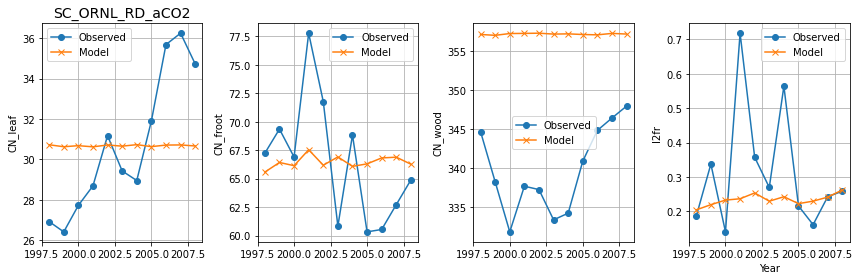

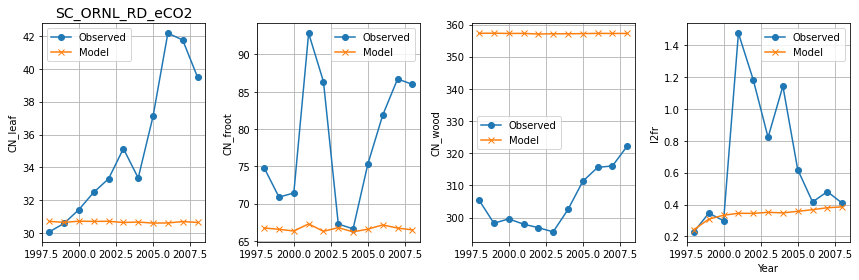

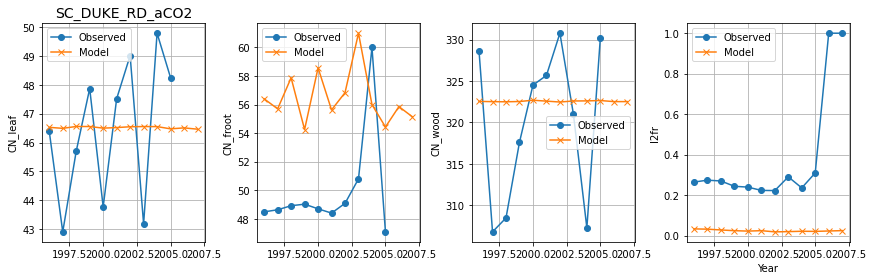

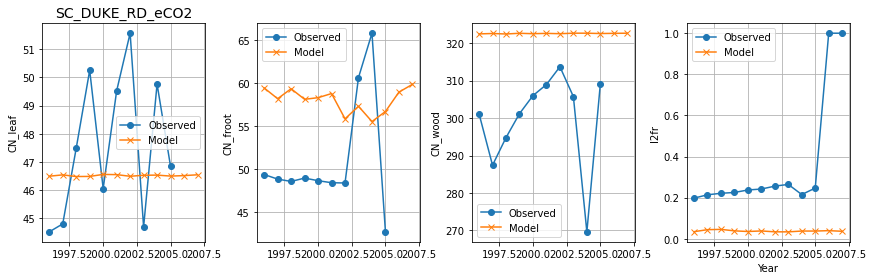

In [158]:
fn   = "RD"

for site in ["ORNL", "DUKE"]:
    for co2 in ["aCO2","eCO2"]:
        obs    = dict_obs[f"{site}_{co2}"]
        models = dict_CN [f"{case_plot}_{site}_{fn}_{co2}"]

        # Set up a list of variable names
        variables = ["CN_leaf", "CN_froot", "CN_wood", "l2fr"]

        # Create a figure with subplots for each variable
        fig, axes = plt.subplots( 1, len(variables), figsize=(12, 4), sharex=True)

        for i, var in enumerate(variables):
            ax = axes[i]
            ax.plot(obs["Year"], obs[var], label="Observed", marker='o')
            ax.plot(models["Year"], models[var], label="Model", marker='x')
            ax.set_ylabel(var)
            ax.legend()
            ax.grid(True)
            if i ==0:
                ax.set_title (f"{case_plot}_{site}_{fn}_{co2}",fontsize=14)
        axes[-1].set_xlabel("Year")
        plt.tight_layout()
        plt.show()


## Plot Model vars only

In [210]:
var_model = "FATES_MORTALITY_CFLUX_USTORY"

FATES_MORTALITY_CFLUX_USTORY :  flux of biomass carbon from live to dead pools from mortality of understory plants in kg carbon per m2 per second
FATES_MORTALITY_CFLUX_CANOPY :  flux of biomass carbon from live to dead pools from mortality of canopy plants in kg carbon per m2 per second
FATES_MORTALITY_CFLUX_PF :  PFT-level flux of biomass carbon from live to dead pool from mortality


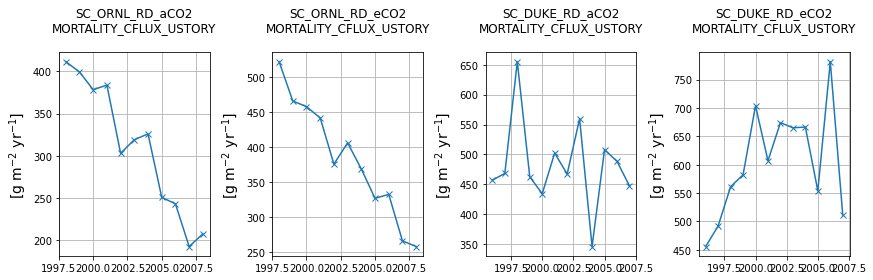

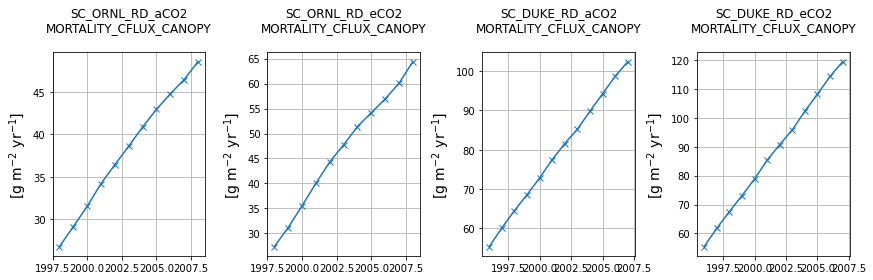

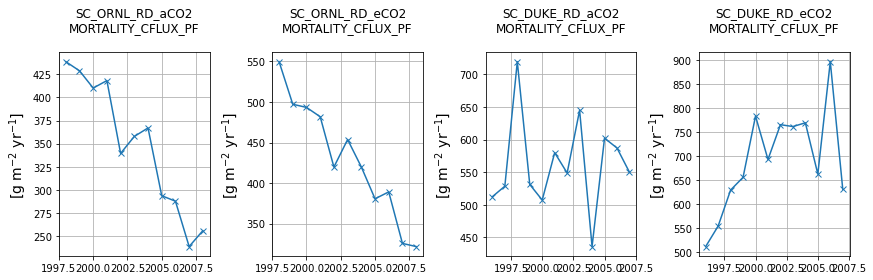

In [211]:
for var_model in ["FATES_MORTALITY_CFLUX_USTORY",
                  "FATES_MORTALITY_CFLUX_CANOPY",
                  "FATES_MORTALITY_CFLUX_PF"]:  
    print (var_model, ": " , ds[key][var_model].long_name)
    fn   = "RD"
    i=0
    fig, axes = plt.subplots( 1, 4, figsize=(12, 4))
    for site in ["ORNL", "DUKE"]:
        for co2 in ["aCO2","eCO2"]:
            key  = f"{case_plot}_{site}_{fn}_{co2}"

            # Select only relevant variables
            ds_selected = ds[key][var_model]
            annual_means = ds_selected.groupby('time.year').mean(dim='time')
            df_annual = annual_means.to_dataframe().reset_index().rename(columns={'year': 'Year'})
            #df_annual = df_annual.round(5)
            # Create a figure with subplots for each variable
            ax = axes[i]
            if ds_selected.units == 'kg m-2 s-1':
                ax.plot(df_annual["Year"], df_annual[var_model]*24*3600*365*1000, label="Model", marker='x')
                ax.set_ylabel(r"[g m$^{-2}$ yr$^{-1}$]", fontsize=14)
            else:
                ax.plot(df_annual["Year"], df_annual[var_model], label="Model", marker='x')
                ax.set_ylabel(ds_selected.units)
            ax.set_title (f"{key}\n{'_'.join(var_model.split('_')[1:])}\n",fontsize=12)
            ax.grid(True)
            plt.tight_layout()
            i=i+1


FATES_MORTALITY_CFLUX_USTORY :  flux of biomass carbon from live to dead pools from mortality of understory plants in kg carbon per m2 per second
FATES_MORTALITY_CFLUX_CANOPY :  flux of biomass carbon from live to dead pools from mortality of canopy plants in kg carbon per m2 per second
FATES_MORTALITY_CFLUX_PF :  PFT-level flux of biomass carbon from live to dead pool from mortality


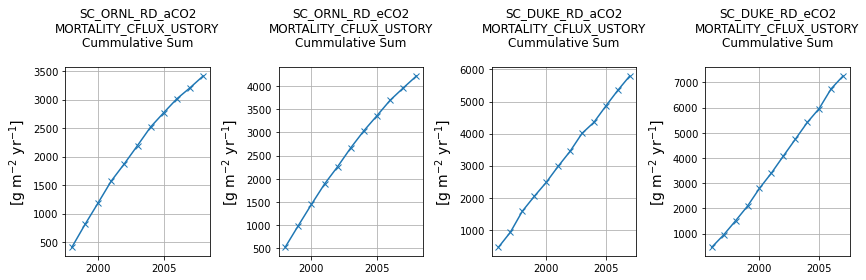

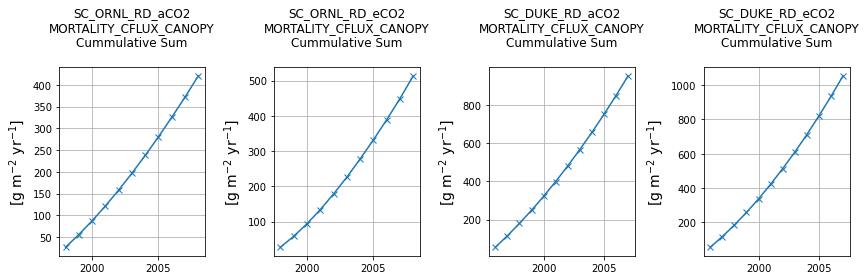

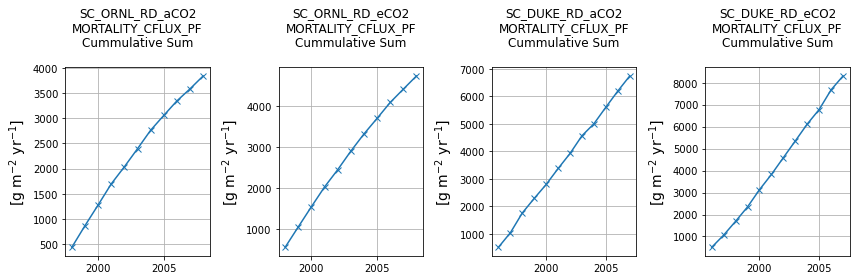

In [222]:
# Cummulative sum
for var_model in ["FATES_MORTALITY_CFLUX_USTORY",
                  "FATES_MORTALITY_CFLUX_CANOPY",
                  "FATES_MORTALITY_CFLUX_PF"]:  
    print (var_model, ": " , ds[key][var_model].long_name)
    fn   = "RD"
    i=0
    fig, axes = plt.subplots( 1, 4, figsize=(12, 4))
    for site in ["ORNL", "DUKE"]:
        for co2 in ["aCO2","eCO2"]:
            key  = f"{case_plot}_{site}_{fn}_{co2}"

            # Select only relevant variables
            ds_selected = ds[key][var_model]
            annual_means = ds_selected.groupby('time.year').mean(dim='time').cumsum()
            df_annual = annual_means.to_dataframe().reset_index().rename(columns={'year': 'Year'})
            #df_annual = df_annual.round(5)
            # Create a figure with subplots for each variable
            ax = axes[i]
            if ds_selected.units == 'kg m-2 s-1':
                ax.plot(df_annual["Year"], df_annual[var_model]*24*3600*365*1000, label="Model", marker='x')
                ax.set_ylabel(r"[g m$^{-2}$ yr$^{-1}$]", fontsize=14)
            else:
                ax.plot(df_annual["Year"], df_annual[var_model], label="Model", marker='x')
                ax.set_ylabel(ds_selected.units)
            ax.set_title (f"{key}\n{'_'.join(var_model.split('_')[1:])}\nCummulative Sum\n",fontsize=12)
            ax.grid(True)
            plt.tight_layout()
            i=i+1
